# Notebook for constructing age models for the North Shore Volcanics Southwest Sequence

In [8]:
using Pkg
using Chron
using Plots, DelimitedFiles
using DataFrames, CSV
using Statistics, StatsBase

include("MCR_age_models.jl")

plot_posterior_paths (generic function with 1 method)

## North Shore Volcanics Southwest Sequence



In [9]:
NSVG_SW_Name = ("Top of Ely's Peak basalts", "40th Ave E Icelandite", "Two Harbors Icelandite", "Palisade Rhyolite", "Silver Bay Intrusion") # Et cetera
NSVG_SW_Age           = [ 1100, 1096.75, 1096.18, 1093.94, 1091.61] # Measured ages
NSVG_SW_Age_sigma     = [ 2/2,   0.28/2,  0.32/2,  0.28/2,  0.14/2] # Measured 1-σ uncertainties
NSVG_SW_Height        = [ 370,     2000,  6215,      7980,  8645] # Depths below surface should be negative
NSVG_SW_Age_Sidedness = [+1, 0, 0, 0, +1] # Sidedness (zeros by default: geochron constraints are two-sided). Use -1 for a maximum age and +1 for a minimum age, 0 for two-sided

NSVG_SW_Path = "../code_output/age_models/NSVG_SW" # Where do you want output files to be stored

# construct the section (ChronAgeData object)
NSVG_SW_section = make_ChronAgeData(NSVG_SW_Name, NSVG_SW_Age, NSVG_SW_Age_sigma, NSVG_SW_Height, NSVG_SW_Age_Sidedness, NSVG_SW_Path, Age_Unit="Ma", Height_Unit="m")

ChronAgeData{5}(("Top of Ely's Peak basalts", "40th Ave E Icelandite", "Two Harbors Icelandite", "Palisade Rhyolite", "Silver Bay Intrusion"), [370.0, 2000.0, 6215.0, 7980.0, 8645.0], [0.01, 0.01, 0.01, 0.01, 0.01], [1100.0, 1096.75, 1096.18, 1093.94, 1091.61], [1.0, 0.14, 0.16, 0.14, 0.07], [NaN, NaN, NaN, NaN, NaN], [NaN, NaN, NaN, NaN, NaN], [NaN, NaN, NaN, NaN, NaN], [NaN, NaN, NaN, NaN, NaN], [1.0, 0.0, 0.0, 0.0, 1.0], [0.0, 0.0, 0.0, 0.0, 0.0], [#undef, #undef, #undef, #undef, #undef], (:Chronometer, :Chronometer, :Chronometer, :Chronometer, :Chronometer), [NaN NaN … NaN NaN; NaN NaN … NaN NaN; … ; NaN NaN … NaN NaN; NaN NaN … NaN NaN], "../code_output/age_models/NSVG_SW", 2, "Ma", "m", :cdf)

In [10]:
NSVG_SW_age_model_config, NSVG_SW_age_model_mdl, NSVG_SW_age_model_agedist, NSVG_SW_age_model_lldist = run_age_model(NSVG_SW_section, 10, 0.20, 1000, save_results=false, plot_results=false)

┌ Info: Generating stratigraphic age-depth model...
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/OUVJN/src/StratMetropolis.jl:28
┌ Info: Burn-in: 1159000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/OUVJN/src/StratMetropolis.jl:626
Burn-in... 100%|█████████████████████████████████████████| Time: 0:00:00
┌ Info: Collecting sieved stationary distribution: 1159000 steps
└ @ Chron /Users/yimingzhang/.julia/packages/Chron/OUVJN/src/StratMetropolis.jl:689
Collecting... 100%|██████████████████████████████████████| Time: 0:00:01


(StratAgeModelConfiguration(10.0, 1159000, 1000, 1159, 0.2), StratAgeModel([370.0, 380.0, 390.0, 400.0, 410.0, 420.0, 430.0, 440.0, 450.0, 460.0  …  8550.0, 8560.0, 8570.0, 8580.0, 8590.0, 8600.0, 8610.0, 8620.0, 8630.0, 8640.0], [1099.769775713008, 1099.752906627609, 1099.7329138066984, 1099.7170911624457, 1099.7007059900511, 1099.6906383671703, 1099.677195963639, 1099.6589621102746, 1099.6417625912666, 1099.6221566562665  …  1093.0051777881981, 1092.9843533765982, 1092.9717236572126, 1092.95843058761, 1092.9438195114474, 1092.9242039204528, 1092.9094823551322, 1092.8910254433254, 1092.8763199485152, 1092.8592158753538], [0.6507308064855087, 0.6529502525975466, 0.6608382824278348, 0.6619965019220564, 0.6662520059373326, 0.6666010663438503, 0.6658184925645847, 0.666024041834087, 0.6668205309627421, 0.6704197036274175  …  0.5244647894705511, 0.5281584311975445, 0.5300244766421084, 0.5274728048912389, 0.5283027651293115, 0.5327120036670517, 0.5369201971298679, 0.5421744728500687, 0.54640

### posterior summary age model

In [11]:
function plot_age_model(section, mdl; save_figure=false)
    # Plot results (mean and 95% confidence interval for both model and data)
    hdl = plot([mdl.Age_025CI; reverse(mdl.Age_975CI)],[mdl.Height; reverse(mdl.Height)], fill=(round(Int,minimum(mdl.Height)),0.5,:grey), linecolor=:grey, label="model")
    plot!(hdl, mdl.Age, mdl.Height, linecolor=:grey, label="", fg_color_legend=:white) # Center line
    t = section.Age_Sidedness .== 0 # Two-sided constraints (plot in black)
    any(t) && plot!(hdl, section.Age[t], section.Height[t], xerror=2*section.Age_sigma[t],label="data",seriestype=:scatter,color=:black)
    t = section.Age_Sidedness .== 1 # Minimum ages (plot in cyan)
    any(t) && plot!(hdl, section.Age[t], section.Height[t], xerror=(2*section.Age_sigma[t],zeros(count(t))),label="",seriestype=:scatter,color=:grey,msc=:grey)
    # any(t) && zip(section.Age[t], section.Age[t].+nanmean(section.Age_sigma[t])*4, section.Height[t]) .|> x-> plot!([x[1],x[2]],[x[3],x[3]], arrow=true, label="", color=:cyan)
    t = section.Age_Sidedness .== -1 # Maximum ages (plot in orange)
    any(t) && plot!(hdl, section.Age[t], section.Height[t], xerror=(zeros(count(t)),2*section.Age_sigma[t]),label="",seriestype=:scatter,color=:orange,msc=:orange)
    # any(t) && zip(section.Age[t], section.Age[t].-nanmean(section.Age_sigma[t])*4, section.Height[t]) .|> x-> plot!([x[1],x[2]],[x[3],x[3]], arrow=true, label="", color=:orange)
    plot!(hdl, xlabel="Age ($(section.Age_Unit))", ylabel="Height ($(section.Height_Unit))", framestyle=:box)
    # reverse the x axis 
    plot!(hdl, xflip=true)
    # set y axis tick font size 
    plot!(hdl, ytickfont=10, xtickfont=10)
    # put the legend at the bottom right
    plot!(size=(300, 1000), legend=:bottomright, legendfontsize=9, xrotation=45)
    if save_figure
        savefig(hdl,section.Path*"AgeDepthModel.pdf")
    end
    return hdl
end

plot_age_model (generic function with 1 method)

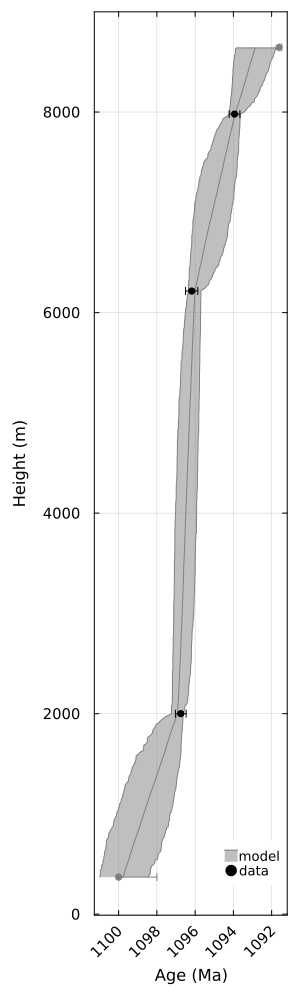

In [12]:
NSVG_SW_age_model = plot_age_model(NSVG_SW_section, NSVG_SW_age_model_mdl, save_figure=false)
plot!(ylim=(-10, 9000), left_margin = 12Plots.mm)
savefig(NSVG_SW_age_model, NSVG_SW_section.Path*"_AgeDepthModel.pdf")
display(NSVG_SW_age_model)

### example posterior accumulation models

  0.072403 seconds (19.00 k allocations: 20.599 MiB, 31.96% gc time)


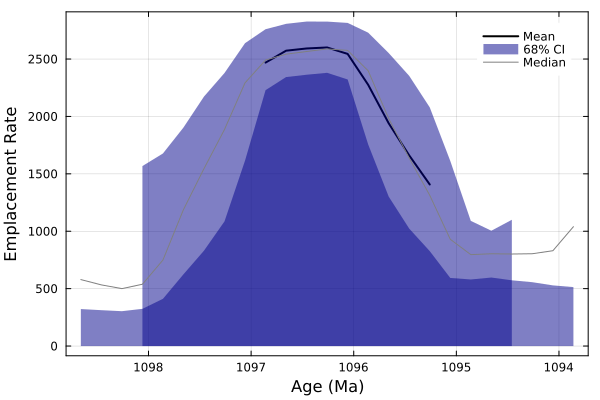

In [13]:
plot_accumulation_model(NSVG_SW_section, NSVG_SW_age_model_config, NSVG_SW_age_model_mdl, NSVG_SW_age_model_agedist, save_figure=false)

### example posterior age models

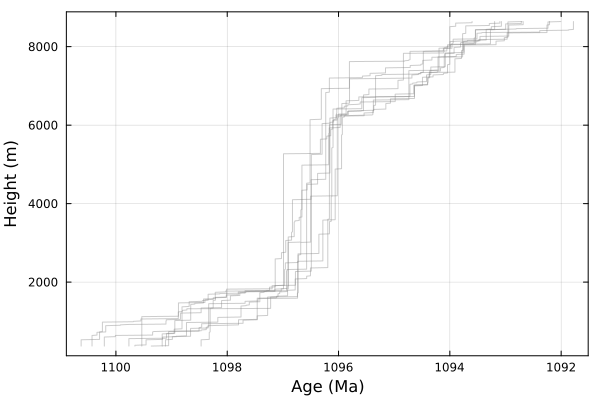

In [14]:
plot_posterior_paths(NSVG_SW_section, NSVG_SW_age_model_agedist, NSVG_SW_age_model_mdl)

## save the age models to a file

In [15]:
NSVG_SW_age_model_agedist

828×1000 Matrix{Float64}:
 1099.12  1099.78  1100.82  1099.23  …  1099.58  1099.92  1100.35  1099.7
 1099.12  1099.78  1100.82  1099.23     1099.58  1099.92  1100.35  1099.7
 1099.12  1099.78  1100.82  1099.23     1099.58  1099.92  1100.35  1099.7
 1099.12  1099.78  1100.82  1099.23     1099.58  1099.86  1100.35  1099.7
 1099.12  1099.78  1100.82  1099.23     1099.58  1099.86  1100.31  1099.7
 1099.12  1099.78  1100.82  1099.23  …  1099.58  1099.86  1100.31  1099.7
 1099.12  1099.78  1100.82  1099.23     1099.58  1099.86  1100.31  1099.7
 1099.12  1099.78  1100.82  1099.23     1099.58  1099.86  1100.31  1099.7
 1099.12  1099.78  1100.82  1099.23     1099.58  1099.86  1100.31  1099.7
 1099.12  1099.78  1100.82  1099.23     1099.58  1099.86  1100.31  1099.7
    ⋮                                ⋱                             
 1093.03  1092.68  1092.58  1092.68     1093.76  1092.1   1093.01  1093.25
 1093.03  1092.68  1092.58  1092.68  …  1093.76  1092.1   1092.87  1093.25
 1093.03  1092.6

In [16]:
# use the mdl.height as index, agedist as the data
NSVG_SW_age_models_df = DataFrame(hcat(NSVG_SW_age_model_mdl.Height, NSVG_SW_age_model_agedist), :auto)
# rename the first three columns to be site, height
rename!(NSVG_SW_age_models_df, Dict(:x1 => "height"))
NSVG_SW_age_models_df

Row,height,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25,x26,x27,x28,x29,x30,x31,x32,x33,x34,x35,x36,x37,x38,x39,x40,x41,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51,x52,x53,x54,x55,x56,x57,x58,x59,x60,x61,x62,x63,x64,x65,x66,x67,x68,x69,x70,x71,x72,x73,x74,x75,x76,x77,x78,x79,x80,x81,x82,x83,x84,x85,x86,x87,x88,x89,x90,x91,x92,x93,x94,x95,x96,x97,x98,x99,x100,⋯
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,⋯
1,370.0,1099.12,1099.78,1100.82,1099.23,1099.27,1100.36,1099.4,1100.22,1099.32,1099.87,1099.88,1099.85,1100.09,1100.17,1099.94,1100.11,1100.33,1100.01,1098.76,1099.27,1098.91,1098.9,1100.82,1100.17,1099.62,1100.33,1100.77,1100.26,1099.54,1099.88,1100.05,1099.35,1099.3,1099.1,1100.99,1099.25,1099.8,1098.75,1099.47,1099.22,1099.77,1099.96,1099.26,1099.52,1100.49,1100.11,1100.22,1099.39,1099.56,1099.52,1099.52,1098.46,1098.69,1099.9,1099.91,1100.71,1100.35,1100.36,1100.26,1099.96,1100.05,1100.04,1100.76,1100.88,1100.16,1099.48,1099.32,1098.94,1099.11,1100.44,1099.4,1098.62,1098.87,1098.33,1100.51,1099.92,1099.71,1099.66,1099.49,1099.27,1099.43,1101.52,1099.63,1099.38,1100.29,1099.82,1099.54,1099.29,1099.7,1099.54,1099.0,1098.84,1098.33,1099.9,1099.3,1100.03,1099.08,1099.9,1100.11,⋯
2,380.0,1099.12,1099.78,1100.82,1099.23,1098.78,1100.36,1099.37,1100.22,1099.32,1099.87,1099.88,1099.85,1100.09,1100.17,1099.94,1100.11,1099.96,1100.01,1098.3,1099.27,1098.91,1098.9,1100.82,1100.17,1099.62,1100.33,1100.77,1100.26,1099.54,1099.88,1100.05,1099.16,1099.3,1099.1,1100.99,1099.25,1099.8,1098.75,1099.47,1099.22,1099.77,1099.96,1099.26,1099.52,1100.49,1100.11,1100.22,1099.39,1099.56,1099.52,1099.52,1098.35,1098.69,1099.9,1099.91,1100.71,1100.35,1100.36,1100.26,1099.96,1100.05,1100.04,1100.76,1100.88,1099.62,1099.48,1099.32,1098.94,1099.11,1100.44,1099.4,1098.62,1098.87,1098.33,1100.51,1099.92,1099.71,1099.66,1099.49,1099.27,1099.43,1101.52,1099.63,1099.38,1100.29,1099.82,1099.54,1099.29,1099.7,1099.54,1099.0,1098.84,1098.33,1099.9,1099.3,1100.03,1099.07,1099.9,1100.11,⋯
3,390.0,1099.12,1099.78,1100.82,1099.23,1098.78,1100.36,1099.37,1100.22,1099.32,1099.87,1099.88,1099.85,1100.09,1099.69,1099.94,1100.11,1099.96,1100.01,1098.3,1099.27,1098.91,1098.9,1100.82,1100.17,1099.62,1100.33,1100.77,1100.26,1099.54,1099.88,1099.91,1099.16,1099.18,1099.1,1100.99,1099.25,1099.8,1098.75,1099.47,1099.22,1099.77,1099.96,1099.26,1099.52,1100.49,1100.11,1100.22,1099.39,1099.56,1099.52,1099.52,1098.35,1098.69,1099.9,1099.91,1100.71,1100.35,1100.36,1100.26,1099.45,1100.05,1100.04,1100.76,1100.88,1099.62,1099.48,1099.32,1098.94,1099.11,1100.44,1099.4,1098.62,1098.69,1098.33,1100.51,1099.92,1099.71,1099.66,1099.49,1099.27,1099.43,1101.52,1099.63,1099.38,1100.29,1099.62,1099.54,1099.29,1099.44,1099.54,1099.0,1098.84,1098.33,1099.9,1099.3,1100.03,1099.07,1099.9,1100.11,⋯
4,400.0,1099.12,1099.78,1100.82,1099.23,1098.78,1100.36,1099.37,1100.22,1099.17,1099.87,1099.88,1099.85,1100.09,1099.69,1099.94,1100.11,1099.96,1099.8,1098.3,1099.27,1098.91,1098.9,1100.82,1100.17,1099.62,1100.33,1100.77,1100.26,1099.54,1099.88,1099.91,1099.16,1099.18,1099.1,1100.99,1099.25,1099.8,1098.75,1099.47,1099.22,1099.64,1099.96,1099.26,1099.52,1100.49,1100.11,1100.22,1099.39,1099.56,1099.52,1099.52,1098.35,1098

In [17]:
# write the DataFrame to a csv file
CSV.write(NSVG_SW_section.Path*"_posterior_ages.csv", NSVG_SW_age_models_df)

"../code_output/age_models/NSVG_SW_posterior_ages.csv"